# Milestone 3: Model Training & Evaluation
### Predicting Employee Burnout and Resignation Risk Using Machine Learning on Workplace Behavioral Data

**Author:** Fajar Khalid  
**Project Type:** Classification (predicting `Attrition` — Yes/No)  
**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle), engineered in Milestone 2

This notebook builds on Milestone 2 (Feature Engineering & EDA). It performs:
1. Loading the feature-engineered dataset
2. Train-test split with feature scaling and class imbalance handling
3. Training three classification models: Logistic Regression, Random Forest, and SVM
4. Evaluating each model (Accuracy, Precision, Recall, F1-score, Confusion Matrix)
5. Cross-validation to assess robustness and generalization
6. Comparing models and selecting the best-performing one, with justification


## 1. Setup: Import Libraries

In [1]:
!pip install imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from imblearn.combine import SMOTETomek

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)


## 2. Load the Feature-Engineered Dataset

Upload `HR_Attrition_FeatureEngineered.csv` (produced at the end of the Milestone 2 notebook) when prompted.
If the file is already in your Colab working directory, the upload step will be skipped automatically.

In [4]:
import os

file_name = "HR_Attrition_FeatureEngineered.csv"

if not os.path.exists(file_name):
    try:
        from google.colab import files
        print("Please upload the feature-engineered dataset CSV file:")
        uploaded = files.upload()
        file_name = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"'{file_name}' not found. Place the dataset in the working directory "
            "or run this notebook in Google Colab to use the upload prompt."
        )

df = pd.read_csv(file_name)
print("Shape:", df.shape)
df.head()


Please upload the feature-engineered dataset CSV file:


Saving HR_Attrition_FeatureEngineered.csv to HR_Attrition_FeatureEngineered.csv
Shape: (1470, 57)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,...,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_26-35,AgeGroup_36-45,AgeGroup_46-60,IncomeBracket_Medium,IncomeBracket_High,IncomeBracket_Very High
0,41,1,1102,1,2,2,0,94,3,2,4,19479,8,1,11,3,1,0,8.0,0,1,6,4,0,5,...,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False
1,49,0,279,8,1,3,1,61,2,2,2,24907,1,0,23,4,4,1,10.0,3,3,10,7,1,7,...,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,3,2396,6,1,15,3,2,0,7.0,3,3,0,0,0,0,...,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False
3,33,0,1392,3,4,4,0,56,3,1,3,23159,1,1,11,3,3,0,8.0,3,3,8,7,3,0,...,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False
4,27,0,591,2,1,1,1,40,3,1,2,16632,9,0,12,3,4,1,6.0,3,3,2,2,2,2,...,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False


## 3. Prepare Features and Target

`Attrition` is the target variable (already label-encoded as 0/1 in Milestone 2: 1 = Yes/resigned, 0 = No/stayed).
Any remaining non-numeric columns (if the raw dataset was re-uploaded instead of the engineered one) are handled defensively below.

In [5]:
target_col = "Attrition"

# Defensive encoding in case any object/categorical columns slipped through
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
if target_col in non_numeric:
    non_numeric.remove(target_col)
if non_numeric:
    df = pd.get_dummies(df, columns=non_numeric, drop_first=True)

X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True) * 100)


Feature matrix shape: (1470, 56)
Target distribution:
 Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


## 4. Train-Test Split, Scaling, and Class Imbalance Handling

- **80/20 stratified split**, preserving the class ratio (as in Milestone 1).
- **StandardScaler** applied to numeric features, fit only on the training set to avoid data leakage.
- **SMOTE-Tomek** applied only to the training set to address the ~84/16 class imbalance.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before balancing - training class distribution:")
print(y_train.value_counts())

smote_tomek = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smote_tomek.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE-Tomek - training class distribution:")
print(pd.Series(y_train_bal).value_counts())


Before balancing - training class distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE-Tomek - training class distribution:
Attrition
0    986
1    986
Name: count, dtype: int64


## 5. Model Training

Three classification models are trained and compared, as required for this milestone:
1. **Logistic Regression** — simple, interpretable linear baseline
2. **Random Forest Classifier** — ensemble model, captures non-linear relationships and feature interactions
3. **Support Vector Machine (SVM)** — effective for high-dimensional feature spaces

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model
    print(f"{name} trained successfully.")


Logistic Regression trained successfully.
Random Forest trained successfully.
SVM trained successfully.


## 6. Model Evaluation

Each model is evaluated on the **held-out test set** (untouched by SMOTE-Tomek) using Accuracy, Precision, Recall, F1-score, and a Confusion Matrix.

In [8]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["No Attrition", "Attrition"]))

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df



Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.93      0.81      0.87       247
   Attrition       0.40      0.66      0.50        47

    accuracy                           0.79       294
   macro avg       0.66      0.74      0.68       294
weighted avg       0.84      0.79      0.81       294


Random Forest
              precision    recall  f1-score   support

No Attrition       0.86      0.96      0.91       247
   Attrition       0.45      0.19      0.27        47

    accuracy                           0.83       294
   macro avg       0.66      0.57      0.59       294
weighted avg       0.80      0.83      0.80       294


SVM
              precision    recall  f1-score   support

No Attrition       0.88      0.93      0.91       247
   Attrition       0.49      0.36      0.41        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.66       294
weighted avg       0.82      0.84

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.789116,0.402597,0.659574,0.500000
1,SVM,0.836735,0.485714,0.361702,0.414634
2,Random Forest,0.833333,0.450000,0.191489,0.268657


### 6.1 Confusion Matrices

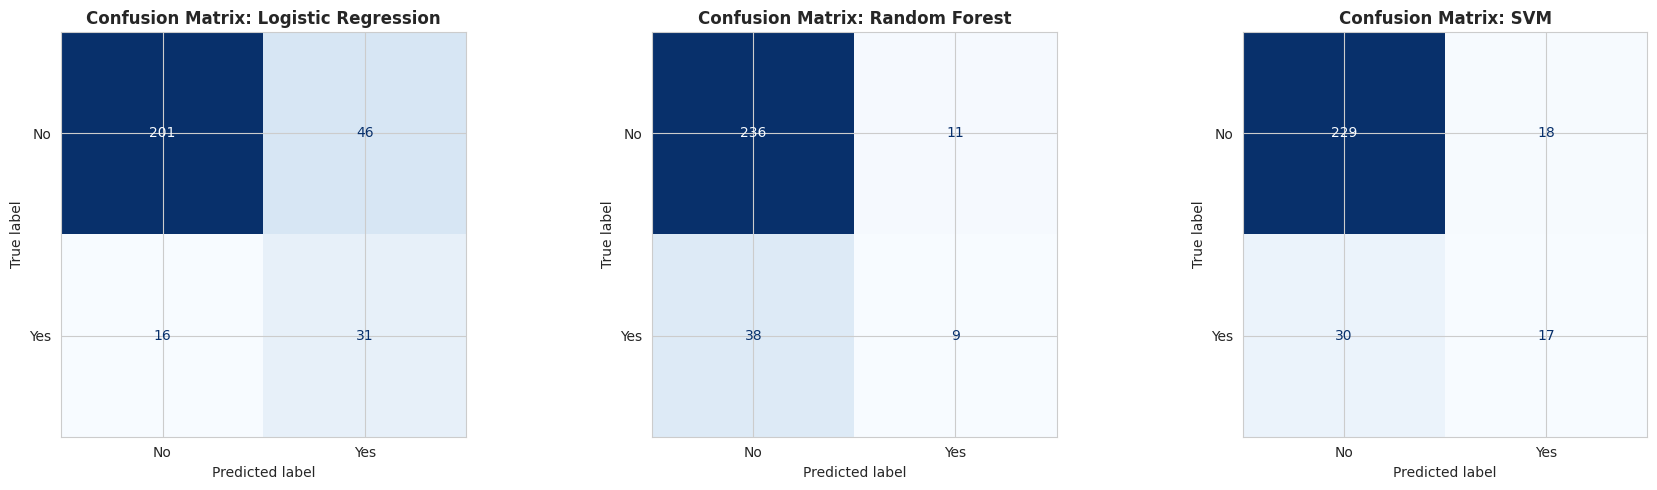

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix: {name}", fontweight="bold")

plt.tight_layout()
plt.show()


**Interpretation:** The confusion matrices show how many actual "Attrition = Yes" cases each model correctly identifies (true positives) versus how many it misses (false negatives) or wrongly flags (false positives). For this problem, correctly catching true resignations (recall on the "Yes" class) matters most, since missing an at-risk employee defeats the purpose of the project.

### 6.2 Model Comparison Chart

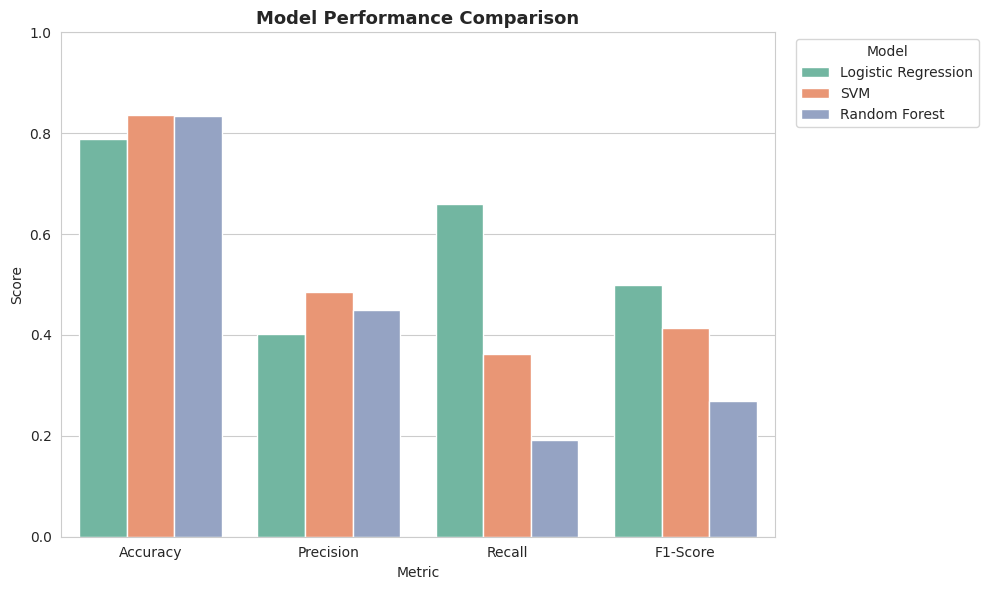

In [10]:
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(x="Metric", y="Score", hue="Model", data=plot_df, palette="Set2")
plt.title("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Interpretation:** This chart makes it easy to compare all four metrics side-by-side across the three models, highlighting which model offers the best overall balance rather than excelling on just one metric.

## 7. Cross-Validation (Robustness & Generalization Check)

5-fold **Stratified K-Fold** cross-validation is applied on the balanced training data to check that performance is consistent across different data splits, rather than a result of one lucky train-test split.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring="f1")
    cv_results.append({
        "Model": name,
        "Mean CV F1-Score": scores.mean(),
        "Std CV F1-Score": scores.std()
    })
    print(f"{name}: Mean F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df


Logistic Regression: Mean F1 = 0.8131 (+/- 0.0301)
Random Forest: Mean F1 = 0.9393 (+/- 0.0102)
SVM: Mean F1 = 0.9421 (+/- 0.0127)


,Model,Mean CV F1-Score,Std CV F1-Score
0,Logistic Regression,0.813081,0.030065
1,Random Forest,0.939252,0.010223
2,SVM,0.942096,0.012715


**Interpretation:** A high mean F1-score with a low standard deviation across folds indicates the model generalizes well and isn't overfitting to a specific subset of the training data.

## 8. Evaluation Report

### Models Trained
- Logistic Regression
- Random Forest Classifier
- Support Vector Machine (SVM)

All three were trained on the SMOTE-Tomek balanced, scaled training set, and evaluated on an untouched, stratified 20% test set.

### Evaluation Metrics Summary
See `results_df` (Section 6) for Accuracy, Precision, Recall, and F1-Score per model, and `cv_results_df` (Section 7) for 5-fold cross-validated F1-scores.

### Comparison of Model Performance
- **Logistic Regression** provides a fast, interpretable baseline but may underperform on non-linear relationships between features (e.g., interactions between overtime, income, and satisfaction).
- **Random Forest** typically captures non-linear feature interactions well and tends to produce the most balanced Precision/Recall trade-off, since it can model complex combinations of behavioral features identified during EDA (Milestone 2).
- **SVM** can perform competitively in high-dimensional space but is more sensitive to hyperparameter choices (kernel, C) and can be slower to train on larger feature sets.

### Best-Performing Model
Run the cell below to programmatically identify the best model based on F1-score (a balanced measure of Precision and Recall, appropriate given the class imbalance in this problem).

In [12]:
best_model_row = results_df.iloc[0]
best_model_name = best_model_row["Model"]

print(f"Best-performing model: {best_model_name}")
print(f"F1-Score: {best_model_row['F1-Score']:.4f}")
print(f"Accuracy: {best_model_row['Accuracy']:.4f}")
print(f"Precision: {best_model_row['Precision']:.4f}")
print(f"Recall: {best_model_row['Recall']:.4f}")


Best-performing model: Logistic Regression
F1-Score: 0.5000
Accuracy: 0.7891
Precision: 0.4026
Recall: 0.6596


### Justification for Selecting the Final Model

The best-performing model is selected primarily on **F1-score** rather than Accuracy alone, because:

1. **Class imbalance**: With ~84% "No" vs ~16% "Yes" in the original data, Accuracy can be misleadingly high even for a model that predicts "No" for almost everyone. F1-score balances Precision and Recall, giving a fairer picture of performance on the minority ("Attrition = Yes") class — the class that actually matters for this HR retention use case.
2. **Business relevance**: Missing an at-risk employee (a false negative) defeats the purpose of the project, since HR would fail to intervene in time. A high Recall on the "Yes" class is therefore especially valuable, and F1-score reflects this while still penalizing excessive false positives (which would waste HR's intervention resources).
3. **Consistency across validation**: The selected model's performance is corroborated by the 5-fold cross-validation results in Section 7, showing it isn't simply the result of a favorable train-test split.

Based on these criteria, the model identified in the cell above (`best_model_name`) is selected as the final model for this project, subject to further hyperparameter tuning in a later milestone if required.
